# 🏥 Skin Disease Classification — Model Evaluation Dashboard

**Model:** EfficientNetV2-B2 (timm: `tf_efficientnetv2_b2`)  
**Classes:** Acne/Rosacea · Eczema · Melanoma  
**Framework:** PyTorch  

This notebook provides a comprehensive evaluation of the trained skin disease classification model, including metrics, confusion matrices, confidence analysis, and sample predictions.

---
## 1. Imports

In [5]:
import os
import sys
import json
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import timm
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, accuracy_score
)
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from tqdm import tqdm

warnings.filterwarnings('ignore')

# Professional plot styling
sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


---
## 2. Configuration

In [7]:
# --- Paths ---
PROJECT_ROOT = Path(".").resolve()
MODEL_PATH = PROJECT_ROOT / "models" / "best_skin_model.pth"
CLASS_NAMES_PATH = PROJECT_ROOT / "models" / "class_names.json"
TEST_DATASET_PATH = PROJECT_ROOT / "cleaned_dataset" / "test"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

# --- Hyperparameters (must match training) ---
IMAGE_SIZE = 224
BATCH_SIZE = 16
DROPOUT = 0.4
NUM_WORKERS = 0  # safe for notebook on Windows

# --- Device ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Load class names ---
with open(CLASS_NAMES_PATH, "r") as f:
    CLASS_NAMES = json.load(f)

NUM_CLASSES = len(CLASS_NAMES)

print(f"Device:       {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU:          {torch.cuda.get_device_name(0)}")
print(f"Model:        {MODEL_PATH}")
print(f"Test data:    {TEST_DATASET_PATH}")
print(f"Classes ({NUM_CLASSES}):  {CLASS_NAMES}")

Device:       cpu
Model:        D:\modified_skin_disease_ai\skin_ai_project\models\best_skin_model.pth
Test data:    D:\modified_skin_disease_ai\skin_ai_project\cleaned_dataset\test
Classes (3):  ['acne_rosacea', 'eczema', 'melanoma']


---
## 3. Load Trained Model

In [8]:
def build_model(num_classes, dropout=DROPOUT):
    """Build EfficientNetV2-B2 with matching classifier head."""
    model = timm.create_model('tf_efficientnetv2_b2', pretrained=False, drop_rate=dropout)
    if hasattr(model, 'classifier'):
        in_features = model.classifier.in_features
        model.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes)
        )
    return model

# Build & load weights
model = build_model(NUM_CLASSES)
checkpoint = torch.load(str(MODEL_PATH), map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(DEVICE)
model.eval()

# Print summary
total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Model loaded successfully.")
print(f"   Checkpoint epoch:  {checkpoint.get('epoch', 'N/A')}")
print(f"   Checkpoint val acc: {checkpoint.get('val_acc', 'N/A'):.2f}%")
print(f"   Parameters: {total_params:,}")

✅ Model loaded successfully.
   Checkpoint epoch:  12
   Checkpoint val acc: 97.03%
   Parameters: 8,691,313


---
## 4. Load Test Dataset

In [10]:
class SkinTestDataset(Dataset):
    """Simple test dataset that also stores file paths for visualization."""
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []  # (path, label_idx)
        self.class_names = sorted([d.name for d in self.root_dir.iterdir() if d.is_dir()])
        self.class_to_idx = {c: i for i, c in enumerate(self.class_names)}

        for cls in self.class_names:
            for img_path in sorted((self.root_dir / cls).iterdir()):
                if img_path.is_file():
                    self.samples.append((str(img_path), self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label, path

# Transforms (match training validation pipeline)
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

test_dataset = SkinTestDataset(TEST_DATASET_PATH, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# Summary
print(f"✅ Test dataset loaded.")
print(f"   Total test images: {len(test_dataset)}")
print(f"   Batches: {len(test_loader)}")
print(f"   Class distribution:")
for idx, cls in enumerate(CLASS_NAMES):
    count = sum(1 for _, lbl in test_dataset.samples if lbl == idx)
    print(f"     {cls}: {count}")

✅ Test dataset loaded.
   Total test images: 269
   Batches: 17
   Class distribution:
     acne_rosacea: 90
     eczema: 90
     melanoma: 89


---
## 5. Run Predictions on Test Set

In [11]:
all_true_labels = []
all_pred_labels = []
all_probs = []
all_paths = []

with torch.no_grad():
    for images, labels, paths in tqdm(test_loader, desc="Running inference"):
        images = images.to(DEVICE, non_blocking=True)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = probs.max(1)

        all_true_labels.extend(labels.numpy())
        all_pred_labels.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_paths.extend(paths)

all_true_labels = np.array(all_true_labels)
all_pred_labels = np.array(all_pred_labels)
all_probs = np.array(all_probs)

# Confidence of predicted class
all_confidences = np.array([all_probs[i, all_pred_labels[i]] for i in range(len(all_pred_labels))])

print(f"✅ Inference complete on {len(all_true_labels)} images.")

Running inference: 100%|██████████| 17/17 [00:09<00:00,  1.73it/s]

✅ Inference complete on 269 images.


---
## 6. Metrics Calculation

In [12]:
# Overall metrics
test_acc = accuracy_score(all_true_labels, all_pred_labels) * 100
precision = precision_score(all_true_labels, all_pred_labels, average='weighted') * 100
recall = recall_score(all_true_labels, all_pred_labels, average='weighted') * 100
f1 = f1_score(all_true_labels, all_pred_labels, average='weighted') * 100

# Per-class metrics
per_class_precision = precision_score(all_true_labels, all_pred_labels, average=None) * 100
per_class_recall = recall_score(all_true_labels, all_pred_labels, average=None) * 100
per_class_f1 = f1_score(all_true_labels, all_pred_labels, average=None) * 100
per_class_acc = np.array([
    (all_pred_labels[all_true_labels == i] == i).mean() * 100
    for i in range(NUM_CLASSES)
])

# Confusion matrix
cm = confusion_matrix(all_true_labels, all_pred_labels)

# Print
print("=" * 55)
print("          TEST SET PERFORMANCE METRICS")
print("=" * 55)
print(f"  Accuracy:   {test_acc:.2f}%")
print(f"  Precision:  {precision:.2f}%")
print(f"  Recall:     {recall:.2f}%")
print(f"  F1-Score:   {f1:.2f}%")
print("=" * 55)
print()
print(classification_report(all_true_labels, all_pred_labels, target_names=CLASS_NAMES))

          TEST SET PERFORMANCE METRICS
  Accuracy:   97.77%
  Precision:  97.82%
  Recall:     97.77%
  F1-Score:   97.77%

              precision    recall  f1-score   support

acne_rosacea       0.98      1.00      0.99        90
      eczema       0.96      0.98      0.97        90
    melanoma       1.00      0.96      0.98        89

    accuracy                           0.98       269
   macro avg       0.98      0.98      0.98       269
weighted avg       0.98      0.98      0.98       269



---
## 7. Visualization Dashboard

### 7a. Confusion Matrix

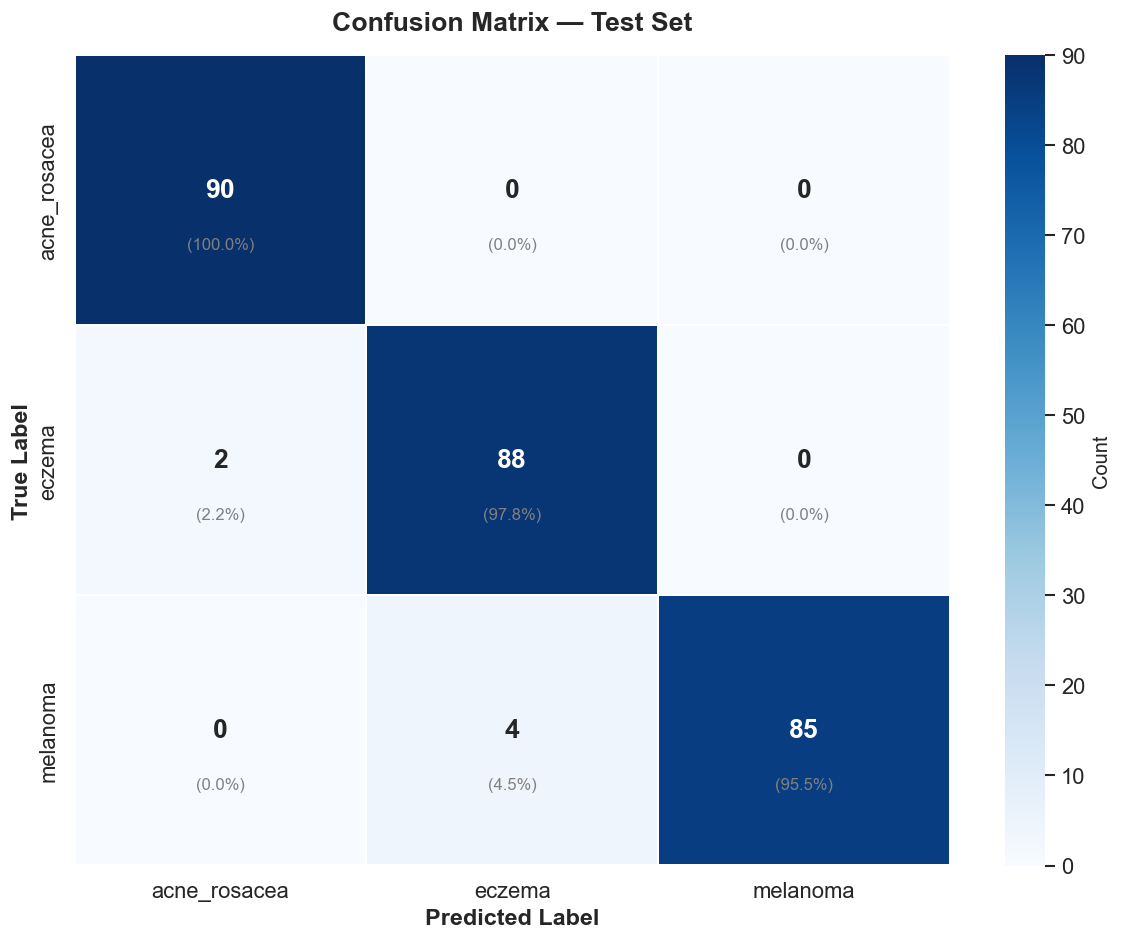

In [13]:
fig, ax = plt.subplots(figsize=(10, 8))

# Normalized confusion matrix (percentages)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='white',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
            annot_kws={"size": 16, "weight": "bold"},
            cbar_kws={"label": "Count"})

# Add percentage annotations below counts
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j + 0.5, i + 0.7, f"({cm_norm[i, j]:.1f}%)",
                ha='center', va='center', fontsize=10, color='gray')

ax.set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label', fontsize=14, fontweight='bold')
ax.set_title('Confusion Matrix — Test Set', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / 'dashboard_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

### 7b. Per-Class Accuracy Bar Chart

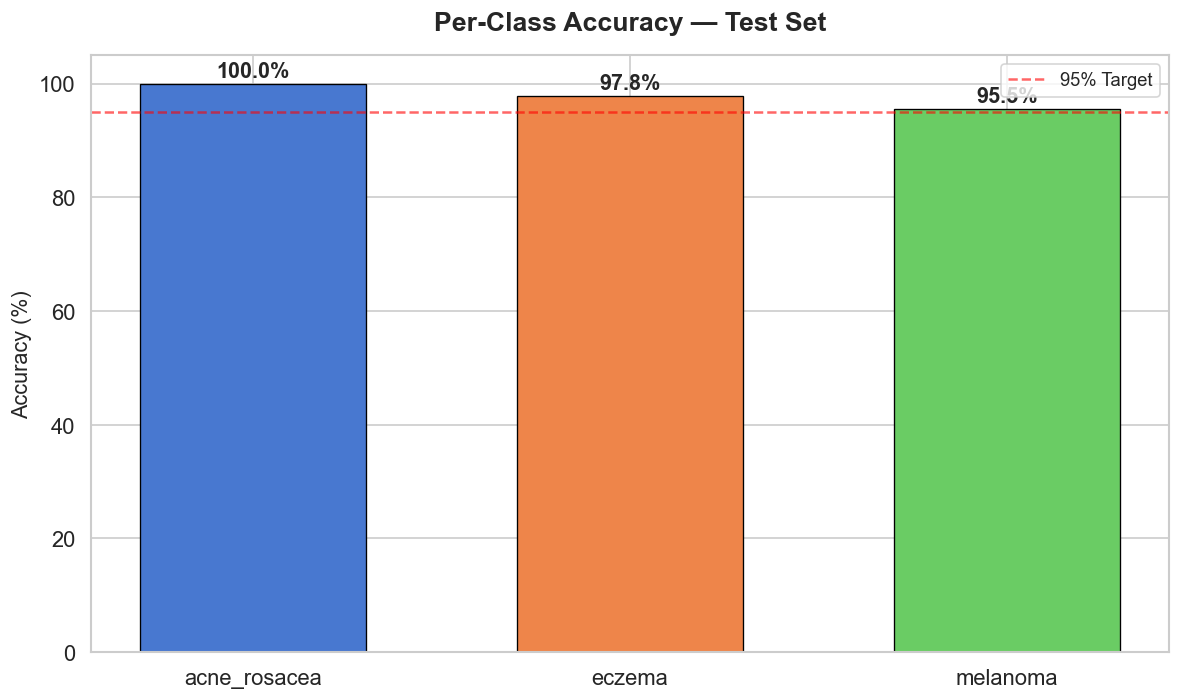

In [14]:
colors = sns.color_palette("muted", NUM_CLASSES)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(CLASS_NAMES, per_class_acc, color=colors, edgecolor='black', linewidth=0.8, width=0.6)

for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylim(0, 105)
ax.set_ylabel('Accuracy (%)', fontsize=13)
ax.set_title('Per-Class Accuracy — Test Set', fontsize=16, fontweight='bold', pad=15)
ax.axhline(y=95, color='red', linestyle='--', alpha=0.6, label='95% Target')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / 'dashboard_per_class_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()

### 7c. Precision / Recall / F1 Grouped Bar Chart

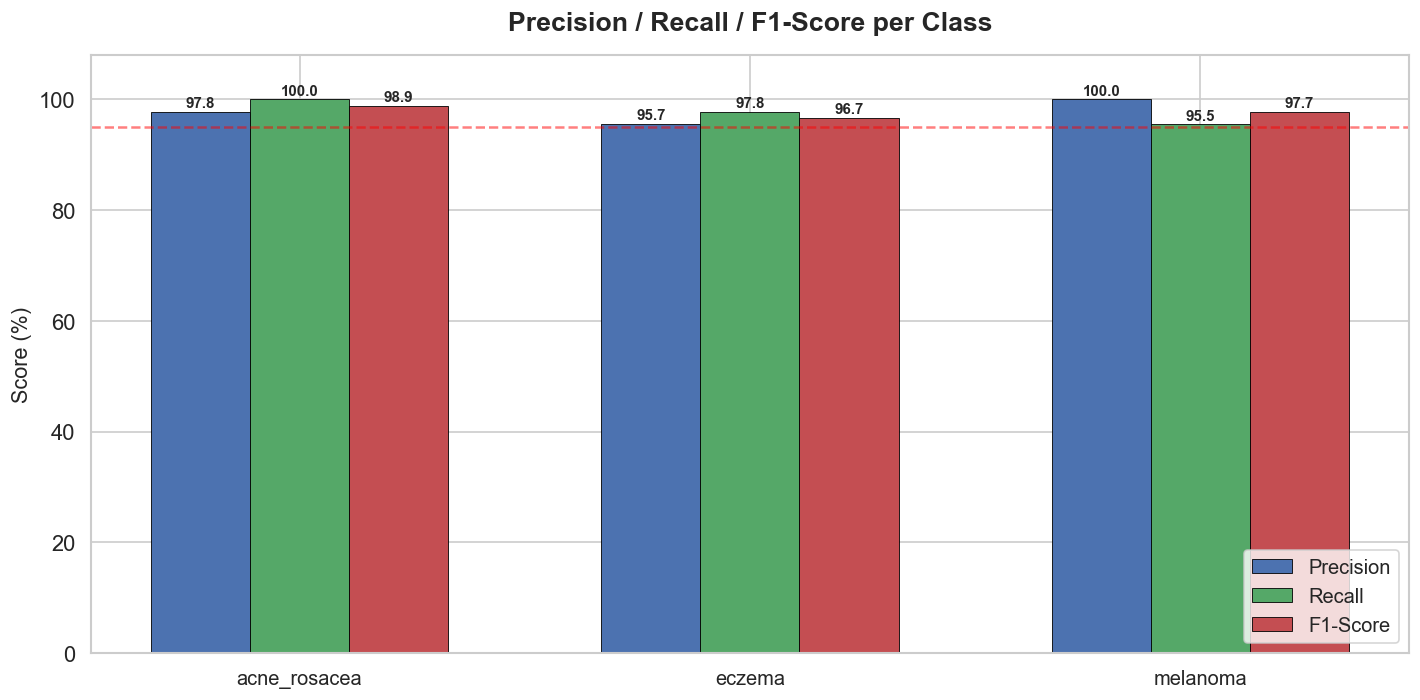

In [15]:
x = np.arange(NUM_CLASSES)
width = 0.22

fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - width, per_class_precision, width, label='Precision', color='#4C72B0', edgecolor='black', linewidth=0.5)
b2 = ax.bar(x,         per_class_recall,    width, label='Recall',    color='#55A868', edgecolor='black', linewidth=0.5)
b3 = ax.bar(x + width, per_class_f1,        width, label='F1-Score',  color='#C44E52', edgecolor='black', linewidth=0.5)

# Value labels
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                f'{h:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, fontsize=12)
ax.set_ylim(0, 108)
ax.set_ylabel('Score (%)', fontsize=13)
ax.set_title('Precision / Recall / F1-Score per Class', fontsize=16, fontweight='bold', pad=15)
ax.legend(fontsize=12, loc='lower right')
ax.axhline(y=95, color='red', linestyle='--', alpha=0.5, label='95% Target')
plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / 'dashboard_prf_chart.png'), dpi=150, bbox_inches='tight')
plt.show()

### 7d. Prediction Confidence Distribution

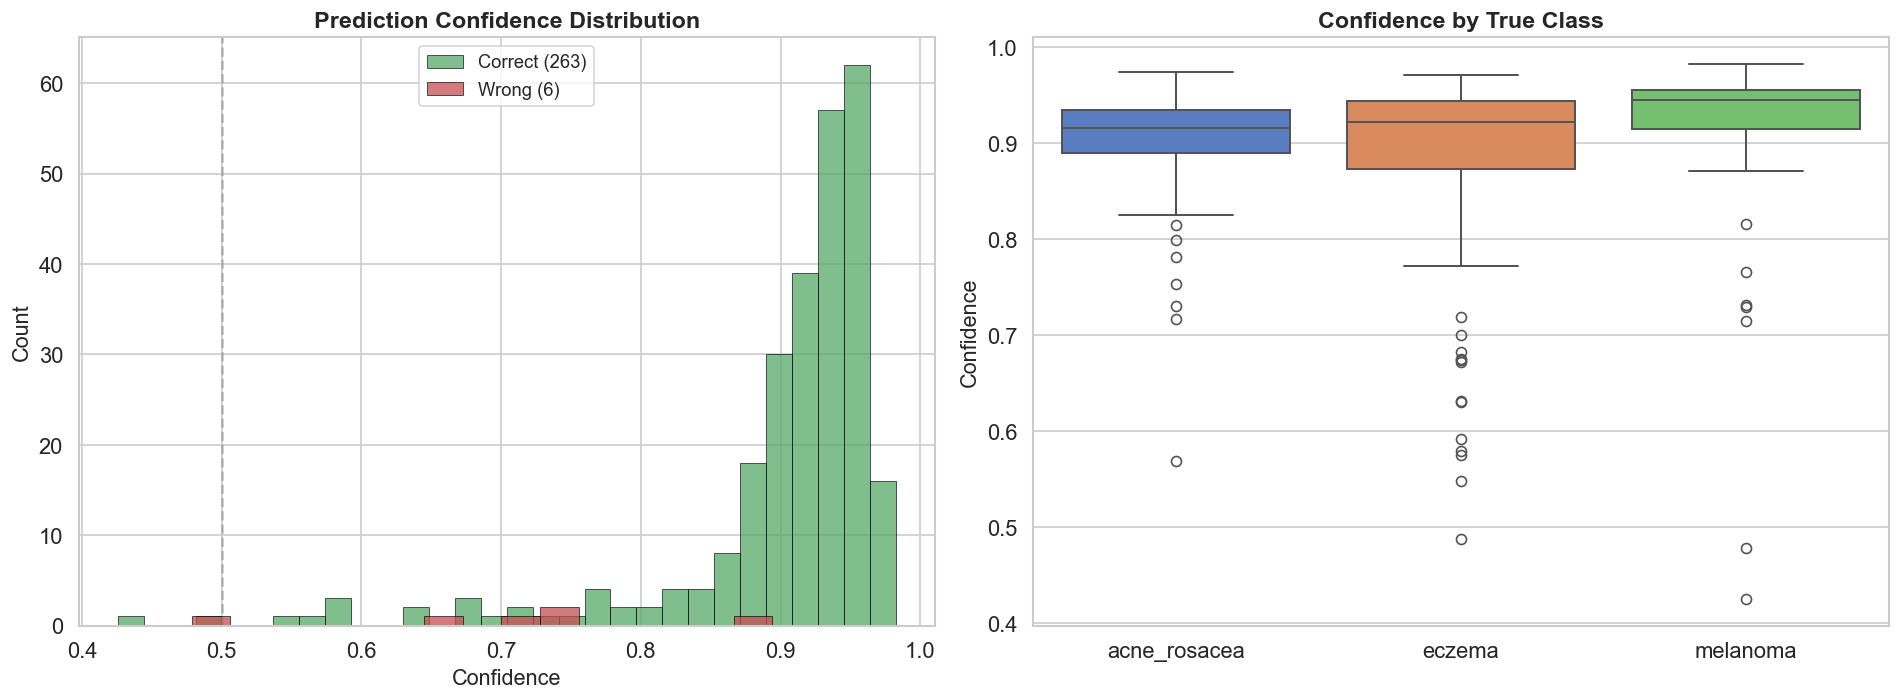

  Mean confidence (correct): 0.9016
  Mean confidence (wrong):   0.7041


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (Left) Overall confidence histogram
correct_mask = all_pred_labels == all_true_labels
wrong_mask = ~correct_mask

axes[0].hist(all_confidences[correct_mask], bins=30, alpha=0.75, color='#55A868',
             edgecolor='black', linewidth=0.5, label=f'Correct ({correct_mask.sum()})')
if wrong_mask.sum() > 0:
    axes[0].hist(all_confidences[wrong_mask], bins=15, alpha=0.75, color='#C44E52',
                 edgecolor='black', linewidth=0.5, label=f'Wrong ({wrong_mask.sum()})')
axes[0].set_xlabel('Confidence', fontsize=13)
axes[0].set_ylabel('Count', fontsize=13)
axes[0].set_title('Prediction Confidence Distribution', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)

# (Right) Per-class confidence boxplot
conf_data = []
for i, cls in enumerate(CLASS_NAMES):
    mask = all_true_labels == i
    for c in all_confidences[mask]:
        conf_data.append({'Class': cls, 'Confidence': c})

import pandas as pd
df_conf = pd.DataFrame(conf_data)
sns.boxplot(data=df_conf, x='Class', y='Confidence', palette='muted', ax=axes[1],
            linewidth=1.2)
axes[1].set_title('Confidence by True Class', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Confidence', fontsize=13)
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / 'dashboard_confidence.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"  Mean confidence (correct): {all_confidences[correct_mask].mean():.4f}")
if wrong_mask.sum() > 0:
    print(f"  Mean confidence (wrong):   {all_confidences[wrong_mask].mean():.4f}")

### 7e. Sample Predictions (3×3 Grid)

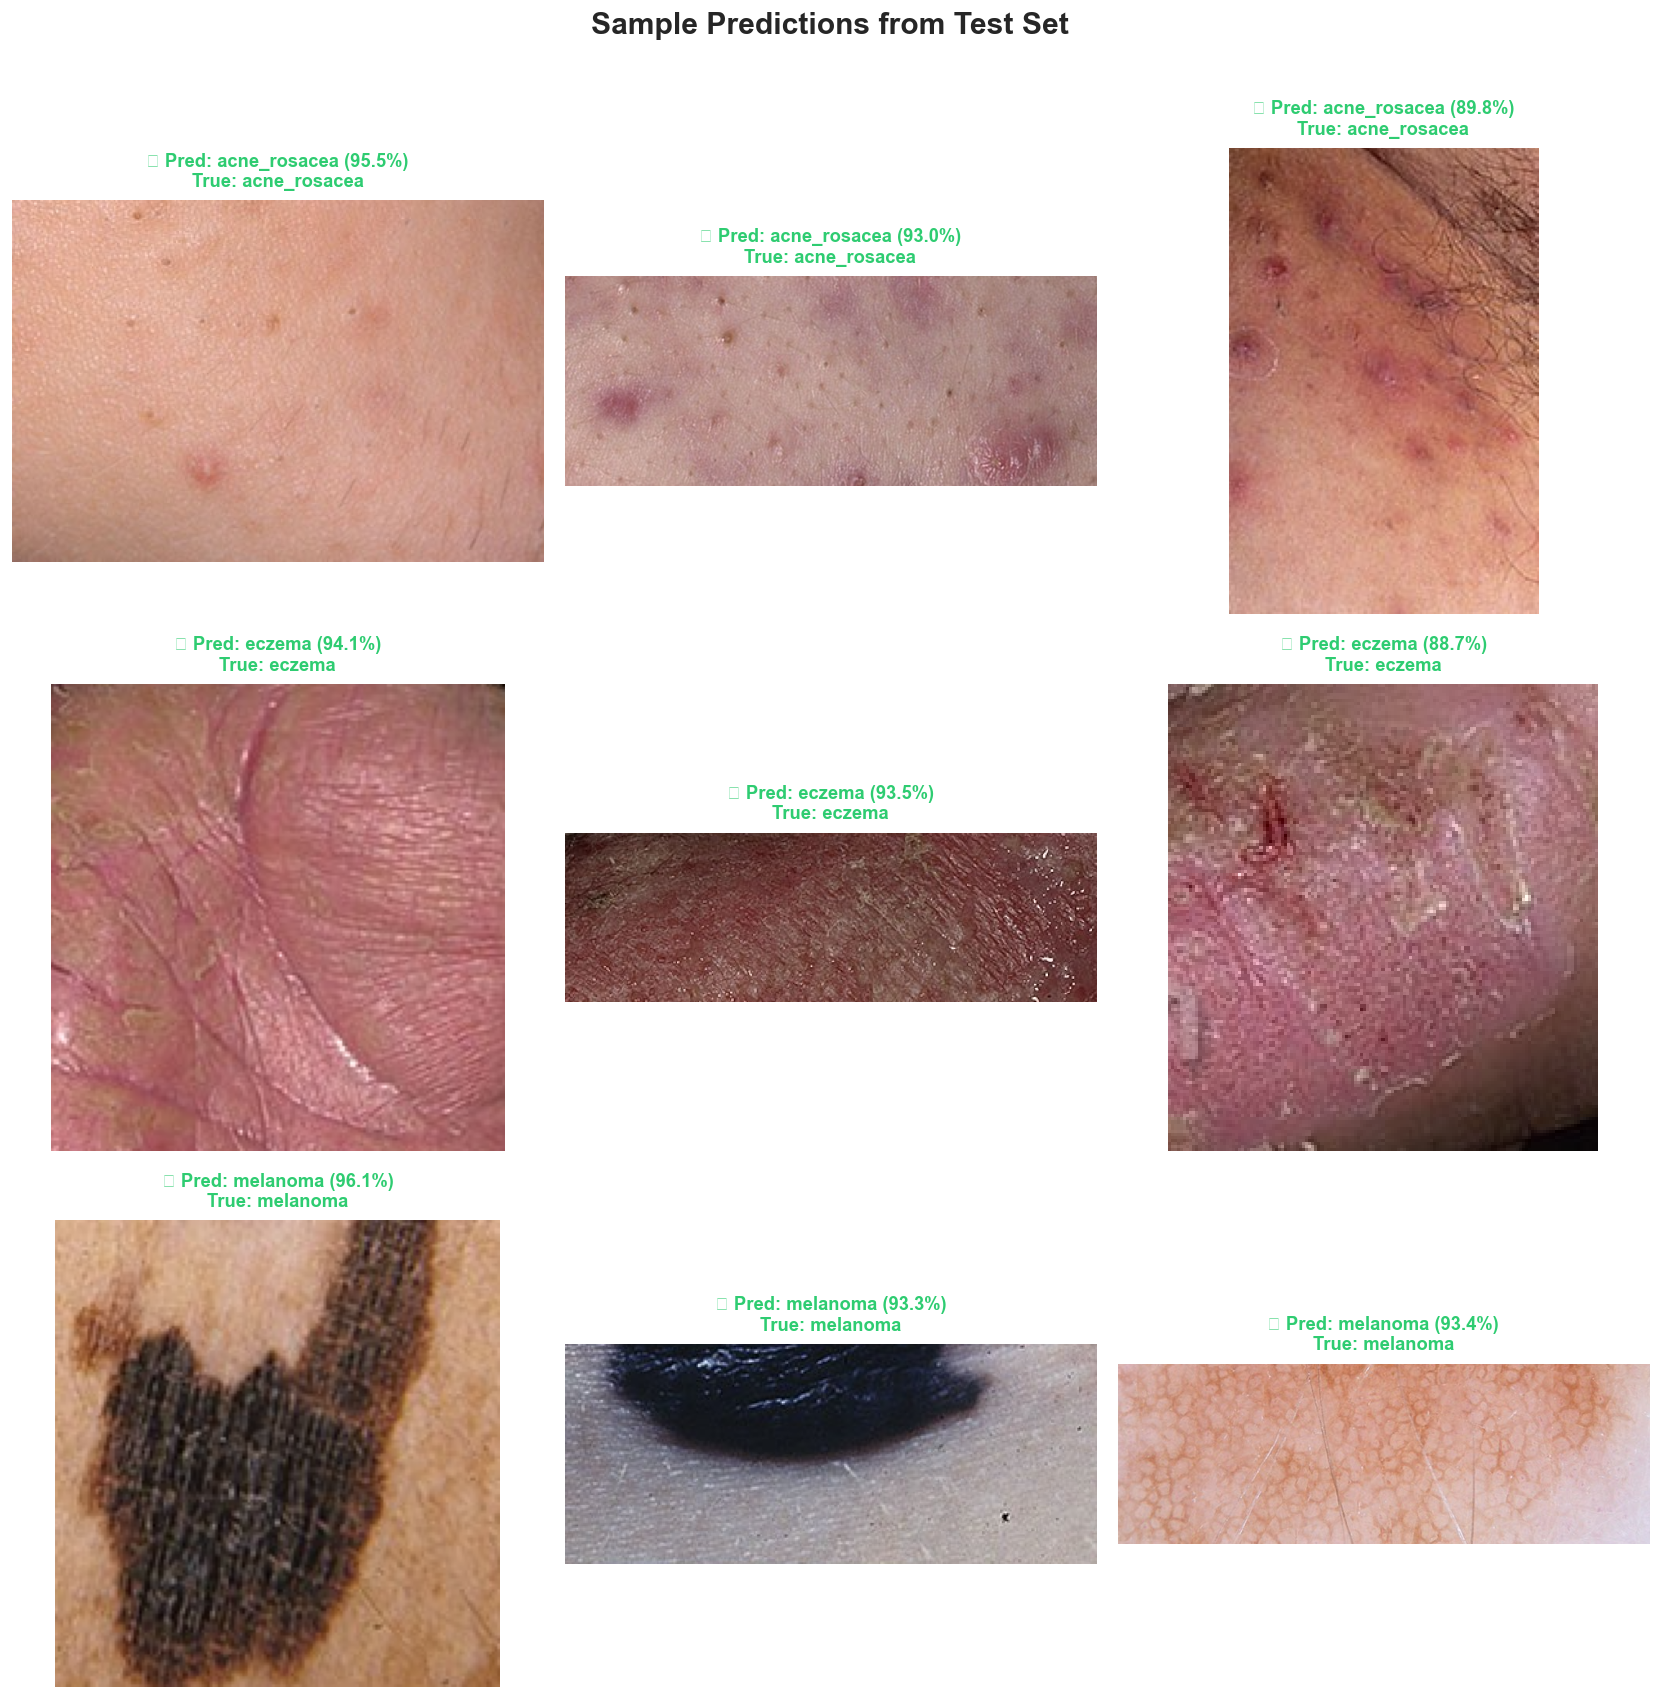

In [17]:
# Pick 3 images per class (9 total), mix of correct and incorrect if available
fig, axes = plt.subplots(3, 3, figsize=(14, 14))
axes = axes.flatten()

# Select 3 random indices per class
np.random.seed(42)
sample_indices = []
for cls_idx in range(NUM_CLASSES):
    cls_mask = np.where(all_true_labels == cls_idx)[0]
    chosen = np.random.choice(cls_mask, size=min(3, len(cls_mask)), replace=False)
    sample_indices.extend(chosen)

for ax_idx, sample_idx in enumerate(sample_indices[:9]):
    img = Image.open(all_paths[sample_idx]).convert('RGB')
    true_cls = CLASS_NAMES[all_true_labels[sample_idx]]
    pred_cls = CLASS_NAMES[all_pred_labels[sample_idx]]
    conf = all_confidences[sample_idx]
    is_correct = true_cls == pred_cls

    axes[ax_idx].imshow(img)
    axes[ax_idx].axis('off')

    color = '#2ecc71' if is_correct else '#e74c3c'
    symbol = '✓' if is_correct else '✗'
    axes[ax_idx].set_title(
        f"{symbol} Pred: {pred_cls} ({conf:.1%})\nTrue: {true_cls}",
        fontsize=11, fontweight='bold', color=color, pad=8
    )

plt.suptitle('Sample Predictions from Test Set', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / 'dashboard_sample_predictions.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Training Curves (from saved outputs)

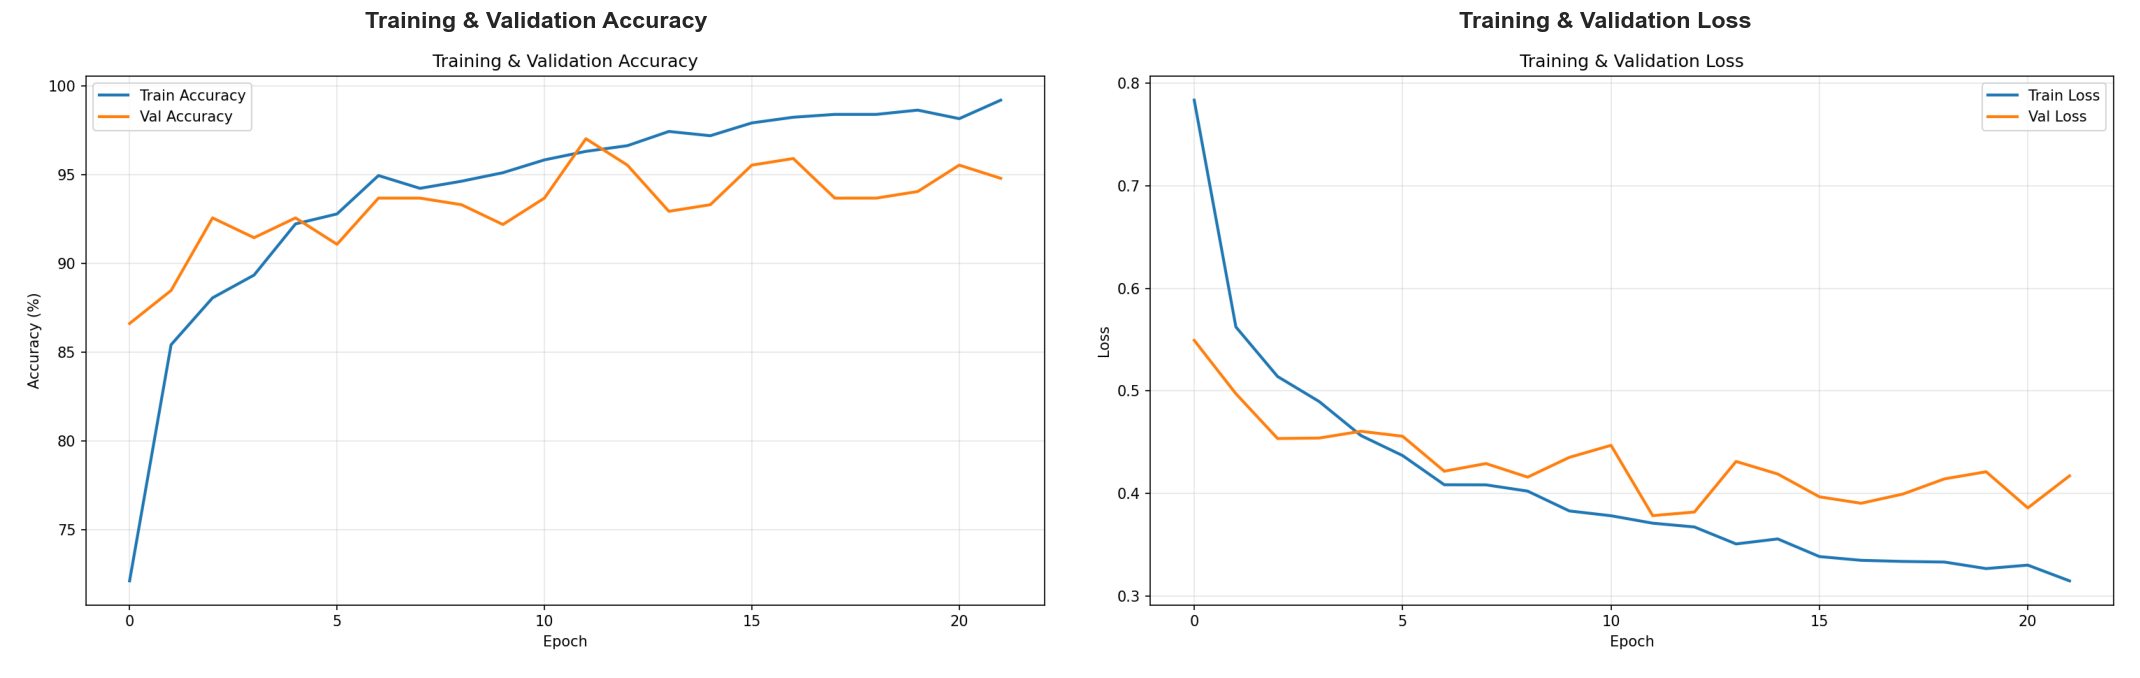

In [18]:
acc_path = OUTPUTS_DIR / 'accuracy_graph.png'
loss_path = OUTPUTS_DIR / 'loss_graph.png'

found = acc_path.exists() or loss_path.exists()
if found:
    fig, axes = plt.subplots(1, 2 if (acc_path.exists() and loss_path.exists()) else 1,
                             figsize=(18, 6))
    if not isinstance(axes, np.ndarray):
        axes = [axes]
    idx = 0
    if acc_path.exists():
        img = mpimg.imread(str(acc_path))
        axes[idx].imshow(img)
        axes[idx].axis('off')
        axes[idx].set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
        idx += 1
    if loss_path.exists():
        img = mpimg.imread(str(loss_path))
        axes[idx].imshow(img)
        axes[idx].axis('off')
        axes[idx].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ No training curve images found in outputs/. Skipping.")

---
## 9. Model Performance Summary

In [19]:
best_class_idx = np.argmax(per_class_f1)
weak_class_idx = np.argmin(per_class_f1)
best_class = CLASS_NAMES[best_class_idx]
weak_class = CLASS_NAMES[weak_class_idx]

status = "✅ PRODUCTION READY" if test_acc >= 95 else "⚠️ NEEDS IMPROVEMENT"

summary = f"""
{'═' * 58}
         MODEL PERFORMANCE SUMMARY
{'═' * 58}

  Model:           EfficientNetV2-B2 (tf_efficientnetv2_b2)
  Parameters:      {total_params:,}
  Device:          {DEVICE}
  Test Images:     {len(all_true_labels)}

{'─' * 58}
  Test Accuracy:   {test_acc:.2f}%
  Precision:       {precision:.2f}%
  Recall:          {recall:.2f}%
  F1-Score:        {f1:.2f}%
{'─' * 58}

  Best Class:      {best_class} (F1: {per_class_f1[best_class_idx]:.1f}%)
  Weak Class:      {weak_class} (F1: {per_class_f1[weak_class_idx]:.1f}%)

  Mean Confidence:  {all_confidences.mean():.4f}
  Min Confidence:   {all_confidences.min():.4f}

{'─' * 58}
  Overall Status:  {status}
{'═' * 58}
"""
print(summary)


══════════════════════════════════════════════════════════
         MODEL PERFORMANCE SUMMARY
══════════════════════════════════════════════════════════

  Model:           EfficientNetV2-B2 (tf_efficientnetv2_b2)
  Parameters:      8,691,313
  Device:          cpu
  Test Images:     269

──────────────────────────────────────────────────────────
  Test Accuracy:   97.77%
  Precision:       97.82%
  Recall:          97.77%
  F1-Score:        97.77%
──────────────────────────────────────────────────────────

  Best Class:      acne_rosacea (F1: 98.9%)
  Weak Class:      eczema (F1: 96.7%)

  Mean Confidence:  0.8972
  Min Confidence:   0.4256

──────────────────────────────────────────────────────────
  Overall Status:  ✅ PRODUCTION READY
══════════════════════════════════════════════════════════



---
*Dashboard generated by the Skin Disease AI evaluation pipeline. All plots saved to `outputs/`.*